# SLR54 Nepali Dataset - How to Use

This notebook demonstrates how to load and use the **Curated Open SLR Nepali Dataset (SLR54)** from the Hugging Face Hub.

The dataset contains audio recordings with transcriptions in Nepali, split into train/validation/test sets.

## 1: Import Required Libraries

In [ ]:
import io
import wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, Audio
from IPython.display import Audio as AudioWidget, display
import warnings
warnings.filterwarnings('ignore')

## 2: Load the Dataset

Load the SLR54 Nepali curated dataset from Hugging Face Hub. The dataset includes three splits: train, validation, and test.

In [2]:
dataset = load_dataset("rughimire/slr54nepali-curated")

# Avoid torchcodec dependency by keeping audio undecoded (bytes + path).
for split in dataset.keys():
    dataset[split] = dataset[split].cast_column("audio", Audio(decode=False))

In [3]:
print("Dataset structure:")
print(dataset)
print("\nSplit sizes:")
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} samples")

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['file_id', 'speaker_id', 'transcript', 'audio_format', 'audio'],
        num_rows: 118256
    })
    validation: Dataset({
        features: ['file_id', 'speaker_id', 'transcript', 'audio_format', 'audio'],
        num_rows: 14774
    })
    test: Dataset({
        features: ['file_id', 'speaker_id', 'transcript', 'audio_format', 'audio'],
        num_rows: 14771
    })
})

Split sizes:
  train: 118256 samples
  validation: 14774 samples
  test: 14771 samples


## 3: Explore Dataset Structure

Let's examine the dataset schema, sample rows, and basic statistics.

In [4]:
print("Dataset features:")
for feature in dataset['train'].features:
    print(f"{feature}")

Dataset features:
file_id
speaker_id
transcript
audio_format
audio


In [5]:
print("\nSample from training set:")
sample = dataset['train'][0]
print(f"File ID: {sample['file_id']}")
print(f"Speaker ID: {sample['speaker_id']}")
print(f"Transcript (Nepali): {sample['transcript']}")
print(f"Audio format: {sample['audio_format']}")
print(f"Audio path metadata: {sample['audio']['path']}")
print(f"Audio bytes length: {len(sample['audio']['bytes'])}")


Sample from training set:
File ID: 5653d74581
Speaker ID: 95a0e
Transcript (Nepali): सर्वसाधारण क्षेत्रमा सुस्पष्ट
Audio format: wav
Audio path metadata: 5653d74581.wav
Audio bytes length: 79550


## 4: Play Audio Samples

Listen to audio samples from the dataset directly in the notebook.

In [7]:
def audio_duration_seconds_from_bytes(audio_bytes):
    with wave.open(io.BytesIO(audio_bytes), "rb") as wav_file:
        frame_count = wav_file.getnframes()
        sample_rate = wav_file.getframerate()
        if sample_rate == 0:
            return 0.0
        return frame_count / sample_rate


def display_sample(dataset_split, index):
    sample = dataset_split[index]
    audio_bytes = sample["audio"]["bytes"]

    print(f"Sample {index}:")
    print(f"  Transcript: {sample['transcript']}")
    print(f"  Speaker ID: {sample['speaker_id']}")
    print(f"  Audio format: {sample['audio_format']}")
    print(f"  Duration: {audio_duration_seconds_from_bytes(audio_bytes):.2f}s")

    # Display audio player directly from wav bytes.
    display(AudioWidget(data=audio_bytes))

In [8]:
# Display sample from training set
print("Training Set Sample:")
display_sample(dataset['train'], 0)

print("\n" + "="*50 + "\n")

# Display sample from validation set
print("Validation Set Sample:")
display_sample(dataset['validation'], 0)

Training Set Sample:
Sample 0:
  Transcript: सर्वसाधारण क्षेत्रमा सुस्पष्ट
  Speaker ID: 95a0e
  Audio format: wav
  Duration: 2.48s




Validation Set Sample:
Sample 0:
  Transcript: पनि भन्ने प्रचलन छ
  Speaker ID: e8b29
  Audio format: wav
  Duration: 2.70s


## 5: Basic Dataset Statistics

Analyze the dataset to understand audio lengths, transcript lengths, and speaker distribution.

In [9]:
# Compute statistics for each split
for split_name in ['train', 'validation', 'test']:
    split_data = dataset[split_name]

    audio_lengths = []
    transcript_lengths = []
    speaker_ids = []

    for sample in split_data:
        audio_length = audio_duration_seconds_from_bytes(sample['audio']['bytes'])
        audio_lengths.append(audio_length)

        transcript_lengths.append(len(sample['transcript']))
        speaker_ids.append(sample['speaker_id'])

    print(f"\n{split_name.upper()} SET STATISTICS:")
    print(f"  Number of samples: {len(split_data)}")
    print(f"  Unique speakers: {len(set(speaker_ids))}")
    print("\n  Audio duration (seconds):")
    print(f"    Min: {min(audio_lengths):.2f}s")
    print(f"    Max: {max(audio_lengths):.2f}s")
    print(f"    Mean: {np.mean(audio_lengths):.2f}s")
    print(f"    Total: {sum(audio_lengths)/3600:.2f} hours")
    print("\n  Transcript length (characters):")
    print(f"    Min: {min(transcript_lengths)}")
    print(f"    Max: {max(transcript_lengths)}")
    print(f"    Mean: {np.mean(transcript_lengths):.1f}")


TRAIN SET STATISTICS:
  Number of samples: 118256
  Unique speakers: 527

  Audio duration (seconds):
    Min: 0.60s
    Max: 27.61s
    Mean: 3.02s
    Total: 99.17 hours

  Transcript length (characters):
    Min: 5
    Max: 128
    Mean: 18.4

VALIDATION SET STATISTICS:
  Number of samples: 14774
  Unique speakers: 527

  Audio duration (seconds):
    Min: 0.67s
    Max: 16.50s
    Mean: 3.01s
    Total: 12.37 hours

  Transcript length (characters):
    Min: 5
    Max: 108
    Mean: 18.3

TEST SET STATISTICS:
  Number of samples: 14771
  Unique speakers: 527

  Audio duration (seconds):
    Min: 0.70s
    Max: 26.40s
    Mean: 3.02s
    Total: 12.40 hours

  Transcript length (characters):
    Min: 5
    Max: 110
    Mean: 18.3


## 6: Visualization

Create visualizations of audio durations and transcript lengths across splits.

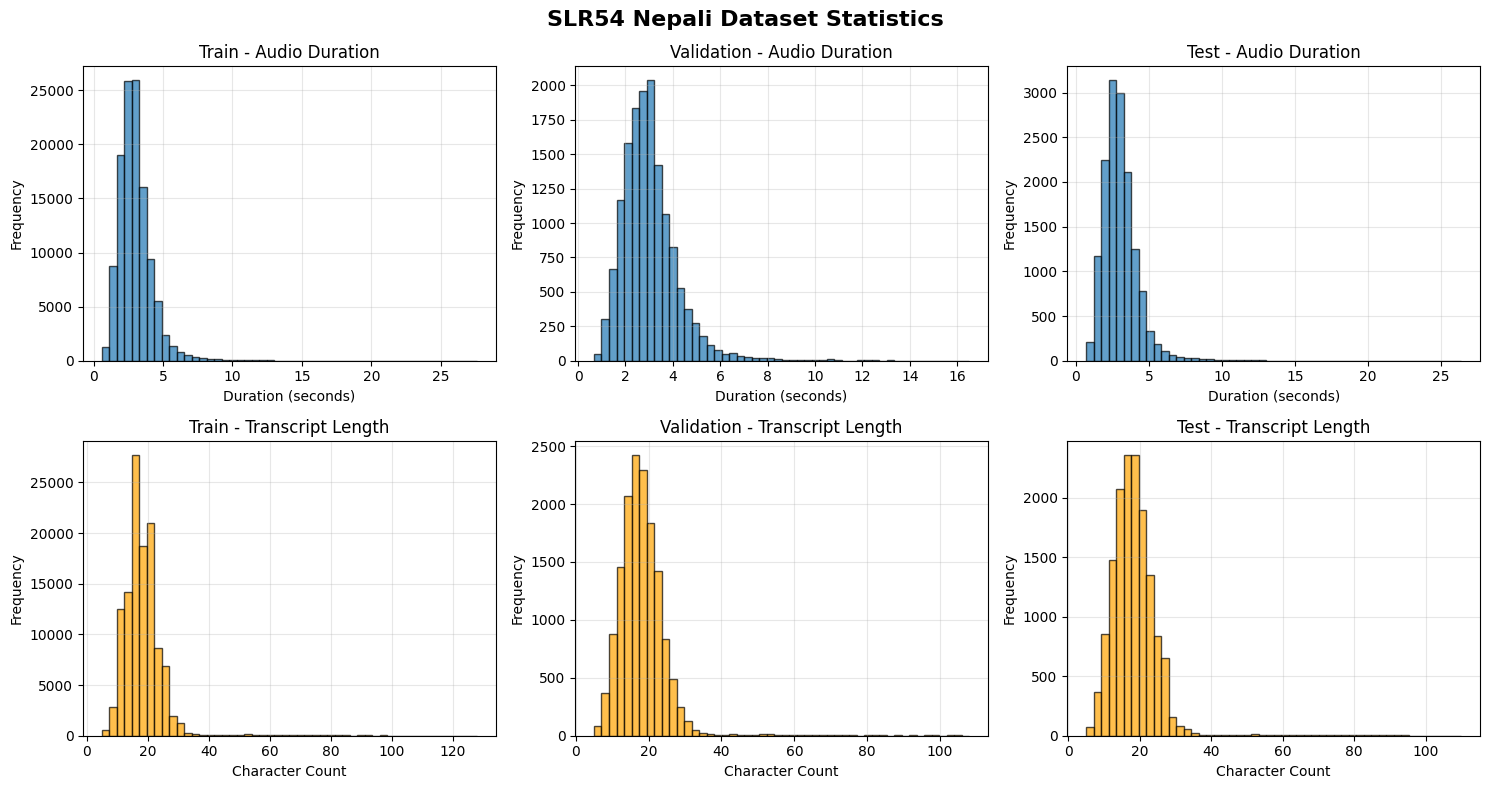

In [10]:
# Collect statistics for visualization
stats_data = {}

for split_name in ['train', 'validation', 'test']:
    split_data = dataset[split_name]

    audio_lengths = []
    transcript_lengths = []

    for sample in split_data:
        audio_length = audio_duration_seconds_from_bytes(sample['audio']['bytes'])
        audio_lengths.append(audio_length)
        transcript_lengths.append(len(sample['transcript']))

    stats_data[split_name] = {
        'audio_lengths': audio_lengths,
        'transcript_lengths': transcript_lengths
    }

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('SLR54 Nepali Dataset Statistics', fontsize=16, fontweight='bold')

splits = ['train', 'validation', 'test']

for idx, split_name in enumerate(splits):
    axes[0, idx].hist(stats_data[split_name]['audio_lengths'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{split_name.capitalize()} - Audio Duration')
    axes[0, idx].set_xlabel('Duration (seconds)')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(alpha=0.3)

    axes[1, idx].hist(stats_data[split_name]['transcript_lengths'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1, idx].set_title(f'{split_name.capitalize()} - Transcript Length')
    axes[1, idx].set_xlabel('Character Count')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7: Usage Examples for ASR Tasks

Examples of how to use this dataset for Automatic Speech Recognition (ASR) or speech processing tasks.

Example 1: Creating a lightweight batch for model input

In [ ]:
def create_audio_batch(dataset_split, batch_size=4):
    import random
    indices = random.sample(range(len(dataset_split)), min(batch_size, len(dataset_split)))

    batch = {
        'audio_bytes': [],
        'durations_sec': [],
        'transcripts': [],
        'file_ids': [],
        'speaker_ids': []
    }

    for idx in indices:
        sample = dataset_split[idx]
        audio_bytes = sample['audio']['bytes']
        batch['audio_bytes'].append(audio_bytes)
        batch['durations_sec'].append(audio_duration_seconds_from_bytes(audio_bytes))
        batch['transcripts'].append(sample['transcript'])
        batch['file_ids'].append(sample['file_id'])
        batch['speaker_ids'].append(sample['speaker_id'])

    return batch

batch = create_audio_batch(dataset['train'], batch_size=4)
print("Created batch with:")
print(f"  - {len(batch['audio_bytes'])} audio samples")
print(f"  - {len(batch['transcripts'])} transcriptions")
print(f"  - Durations (sec): {[round(x, 2) for x in batch['durations_sec']]}")
print("\nTranscriptions in batch:")
for i, (fid, trans) in enumerate(zip(batch['file_ids'], batch['transcripts'])):
    print(f"  {i+1}. [{fid}] {trans}")

Created batch with:
  - 4 audio samples
  - 4 transcriptions
  - Durations (sec): [2.7, 4.02, 1.16, 1.81]

Transcriptions in batch:
  1. [fcb68577a4] सुरु गरे जहाँ उनले
  2. [c32eb0a946] गर्मीको मौसममा न्यूनतम वर्षाको सँगसँगै निकै गर्मी हुन्छ
  3. [525f4d72eb] भनिएको थियो
  4. [20ba94cbdb] यहाँ पुण्यमाता रोशीको


Example 2: Build a tabular frame for downstream preprocessing/modeling

In [ ]:
sample_size = 5
subset = dataset['train'].select(range(sample_size))

rows = []
for sample in subset:
    audio_bytes = sample['audio']['bytes']
    rows.append({
        'file_id': sample['file_id'],
        'speaker_id': sample['speaker_id'],
        'transcript': sample['transcript'],
        'transcript_len': len(sample['transcript']),
        'audio_duration_sec': audio_duration_seconds_from_bytes(audio_bytes),
        'audio_size_bytes': len(audio_bytes),
    })

df = pd.DataFrame(rows)
print("Feature table preview:")
display(df)

Feature table preview:


,file_id,speaker_id,transcript,transcript_len,audio_duration_sec,audio_size_bytes
0,5653d74581,95a0e,सर्वसाधारण क्षेत्रमा सुस्पष्ट,29,2.484563,79550
1,5132f1b7ee,0234b,मान्नुपर्ने देखिन्छ,19,2.700000,86444
2,7f0e523a83,abc37,उनको स्थानमा,12,2.500000,80044
3,01e801b375,68081,जस्तासुकै रचना पनि,18,2.500000,80044
4,5075894b41,6c16b,पक्षमा आवाज उठाउने,18,2.476812,79302


## Next Steps

This notebook demonstrated the basics of loading and exploring the SLR54 Nepali dataset. You can now:

1. **Train an ASR Model**: Use this dataset to fine-tune models like Whisper, Wav2Vec2, or Hubert for Nepali speech recognition.

2. **Data Analysis**: Perform deeper statistical analysis on speaker characteristics, phonetic distributions, or audio quality.

3. **Preprocessing Pipeline**: Build custom preprocessing pipelines for feature extraction (MFCC, mel-spectrograms, etc.).

4. **Multi-task Learning**: Combine transcription with speaker identification or emotion recognition tasks.

For more information about the dataset, visit the [Hugging Face Hub](https://huggingface.co/datasets/rughimire/slr54nepali-curated) or check the repository documentation.